In [7]:
import pandas as pd

data = {
    "study_hours": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 2, 4, 6, 8],
    "attendance": [50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 40, 60, 78, 88],
    "homework_rate": [30, 40, 50, 55, 65, 70, 80, 85, 90, 95, 20, 45, 75, 92],
    "pass_exam": [0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1]
}

df = pd.DataFrame(data)
df

,study_hours,attendance,homework_rate,pass_exam
0,1,50,30,0
1,2,55,40,0
2,3,60,50,0
3,4,65,55,0
4,5,70,65,1
5,6,75,70,1
6,7,80,80,1
7,8,85,85,1
8,9,90,90,1
9,10,95,95,1


In [8]:
X = df[["study_hours", "attendance", "homework_rate"]]
y = df["pass_exam"]

print(X)
print(y)

    study_hours  attendance  homework_rate
0             1          50             30
1             2          55             40
2             3          60             50
3             4          65             55
4             5          70             65
5             6          75             70
6             7          80             80
7             8          85             85
8             9          90             90
9            10          95             95
10            2          40             20
11            4          60             45
12            6          78             75
13            8          88             92
0     0
1     0
2     0
3     0
4     1
5     1
6     1
7     1
8     1
9     1
10    0
11    0
12    1
13    1
Name: pass_exam, dtype: int64


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print("训练集数量：", len(X_train))
print("测试集数量：", len(X_test))

训练集数量： 10
测试集数量： 4


In [10]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [11]:
y_pred = model.predict(X_test)

print("真实结果：", [int(x) for x in y_test])
print("预测结果：", [int(x) for x in y_pred])

真实结果： [1, 0, 0, 1]
预测结果： [1, 0, 0, 1]


In [12]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = float(accuracy_score(y_test, y_pred))
print(f"准确率：{accuracy:.2f}")

print("混淆矩阵：")
print(confusion_matrix(y_test, y_pred).tolist())

print("分类报告：")
print(classification_report(y_test, y_pred, digits=2))

准确率：1.00
混淆矩阵：
[[2, 0], [0, 2]]
分类报告：
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [13]:
new_student = pd.DataFrame({
    "study_hours": [5.5],
    "attendance": [76],
    "homework_rate": [72]
})

pred = model.predict(new_student)
prediction = int(pred[0])

print("预测结果：", prediction)

if prediction == 1:
    print("模型预测：通过考试")
else:
    print("模型预测：不通过考试")

预测结果： 1
模型预测：通过考试


In [14]:
from sklearn.tree import export_text

tree_rules = export_text(
    model,
    feature_names=["study_hours", "attendance", "homework_rate"],
    decimals=2
)

print(tree_rules)

|--- attendance <= 67.50
|   |--- class: 0
|--- attendance >  67.50
|   |--- class: 1



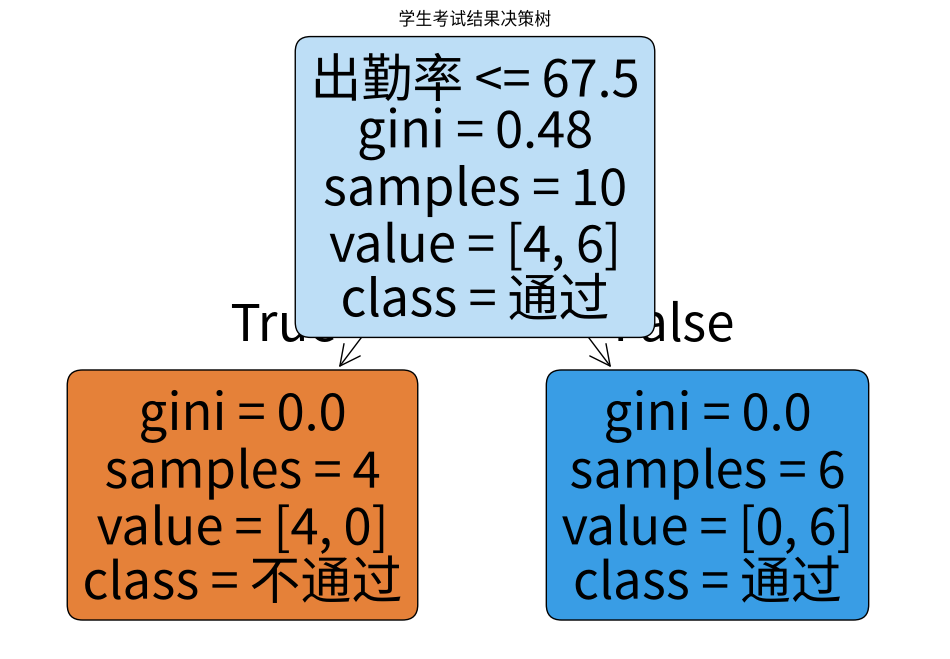

In [15]:
import matplotlib.pyplot as plt
from matplotlib import font_manager
from sklearn.tree import plot_tree

# 直接加载中文字体，避免决策树中的汉字显示为方框
font_path = "/home/penglei/.local/share/fonts/NotoSansCJKsc-Regular.otf"
font_manager.fontManager.addfont(font_path)
font_name = font_manager.FontProperties(fname=font_path).get_name()
plt.rcParams["font.sans-serif"] = [font_name]
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(12, 8))

plot_tree(
    model,
    feature_names=["学习时间", "出勤率", "作业完成率"],
    class_names=["不通过", "通过"],
    filled=True,
    rounded=True,
    precision=2
)

plt.title("学生考试结果决策树")
plt.show()